## Problem
Real estate companies need accurate housing price predictions to support property valuation, investment decisions, and market analysis.

This project builds a machine learning regression model to predict median house prices in California using demographic and geographic features.

# California Housing Price Prediction
1 Problem Statement

2 Dataset Description

3 Import Libraries

4 Load Dataset

5 Exploratory Data Analysis (EDA)

6 Data Cleaning

7 Feature 

8 Train Test 

9 Baseline Model (Linear Regression)

10 Model Evaluation

11 Feature Selection Experiment

12 Advanced Models

13 Model Comparison

14 Business Interpretation

15 Conclusion

16 Future Work

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

# California Housing Price Prediction

## Problem Statement
The objective of this project is to predict the median house value in California districts using housing-related features such as income, house age, rooms, population and geographical location.

This is a supervised machine learning regression problem where the goal is to estimate continuous house prices.

Target Variable:
MedHouseVal (Median House Value)

Machine Learning Type:
Regression


In [5]:
# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target

It contains housing information collected from the 1990 California census.

Number of Samples: 20640

Features:

MedInc – Median income in block group  
HouseAge – Median house age  
AveRooms – Average number of rooms  
AveBedrms – Average bedrooms  
Population – Population of block group  
AveOccup – Average household occupancy  
Latitude – Latitude coordinate  
Longitude – Longitude coordinate  

Target Variable:
MedHouseVal – Median house value for California districts

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the structure of the dataset and relationships between variables.

Steps performed:

• Checked dataset shape  
• Checked missing values  
• Checked duplicate values  
• Statistical summary of data  
• Correlation analysis with target variable

In [7]:
df.shape
print("Dataset Shape:", df.shape)


Dataset Shape: (20640, 9)


In [8]:
df.duplicated().sum()
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.isnull().sum()
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


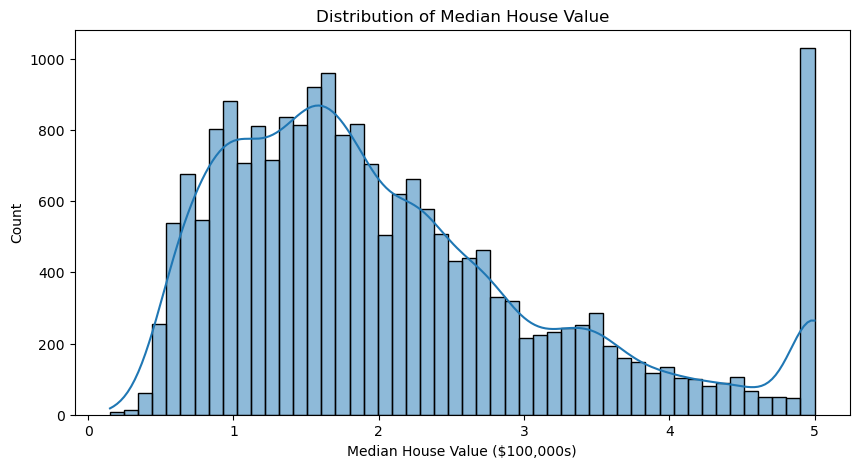

In [10]:
# Target variable distribution
plt.figure(figsize=(10,5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100,000s)')
plt.show()

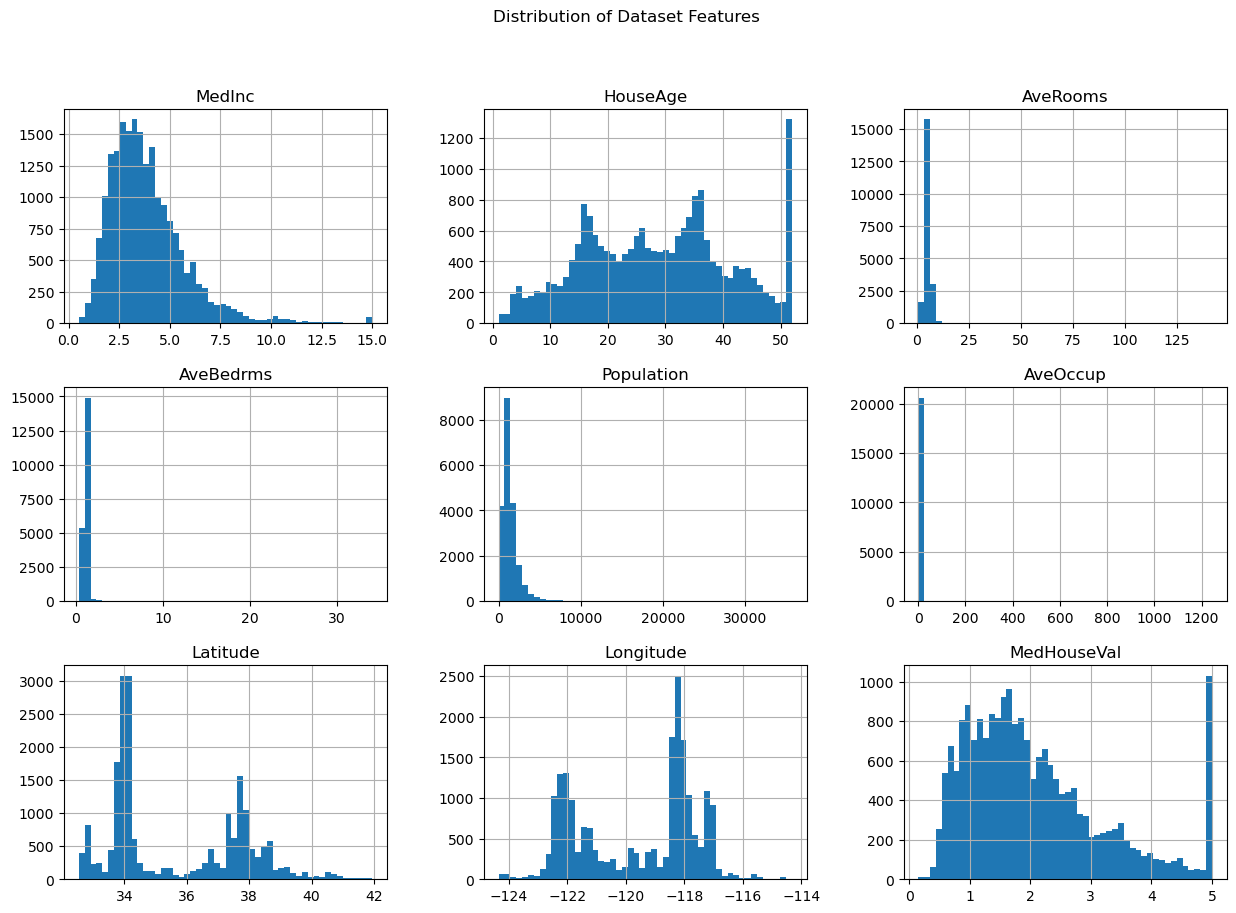

In [11]:
df.hist(bins=50, figsize=(15,10))
plt.suptitle("Distribution of Dataset Features")
plt.show()

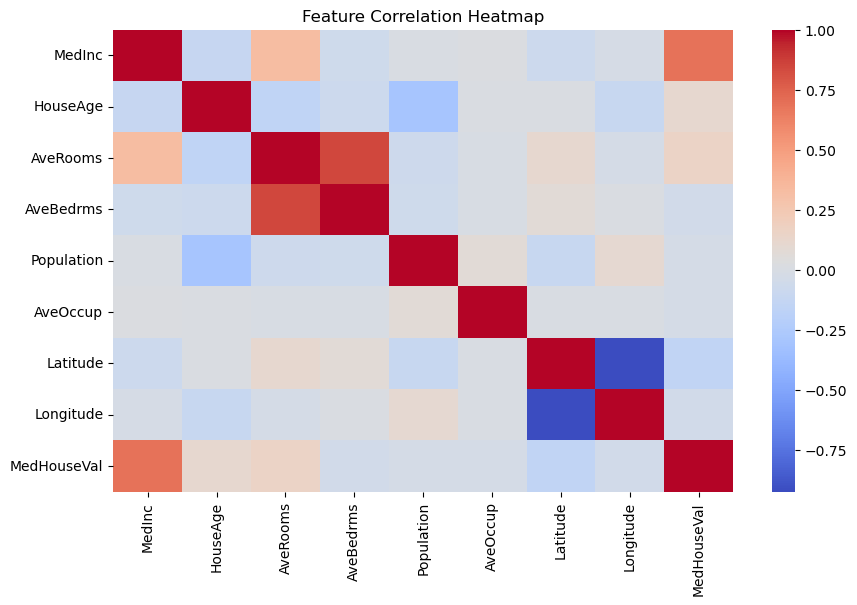

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

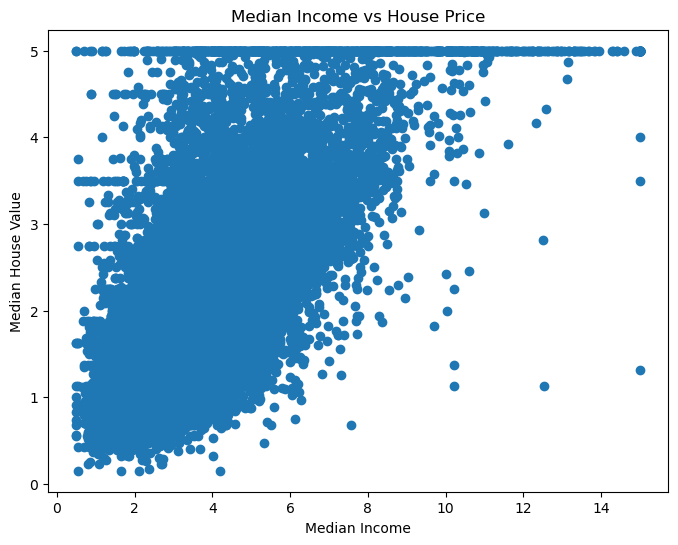

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Price")
plt.show()

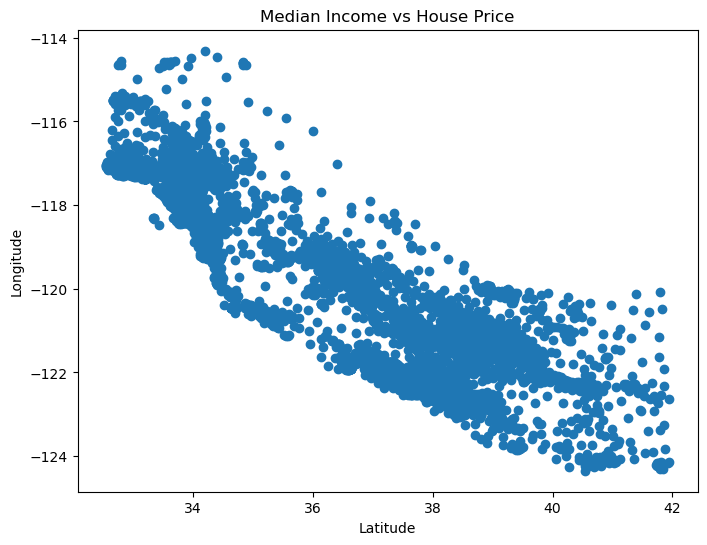

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(df["Latitude"], df["Longitude"], alpha=1)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Median Income vs House Price")
plt.show()

## Data Cleaning

The dataset was checked for common data quality issues.

Steps performed:

• Missing values check  
• Duplicate records check  
• Data type verification  

The dataset did not contain missing values or duplicate entries, so no major cleaning was required.

In [15]:
df["MedHouseVal"].agg(["min", "max"])

min    0.14999
max    5.00001
Name: MedHouseVal, dtype: float64

In [16]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Feature Analysis

Top predictors:
MedInc ,
Latitude ,
Longitude ,
AveRooms

Correlation analysis was performed to identify the relationship between features and the target variable.

Median Income (MedInc) showed the strongest positive correlation with house prices.

Geographical features such as Latitude and Longitude also showed significant influence on house values.

In [17]:
df.corr()["MedHouseVal"].sort_values(ascending=False)
# Median Income has strongest correlation with house price

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [18]:
df["rooms_per_household"] = df["AveRooms"] / df["AveOccup"]
df["bedrooms_per_room"] = df["AveBedrms"] / df["AveRooms"]
df["population_per_household"] = df["Population"] / df["AveOccup"]

In [19]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_household,bedrooms_per_room,population_per_household
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,1.970414,0.224625,330.0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,1.957865,0.215208,114.0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,2.238332,0.215173,433.0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,2.510121,0.219892,349.0


## Baseline Model – Linear Regression

A Linear Regression model was used as the baseline model to predict house prices.

Steps:

• Split dataset into training and testing sets  
• Train Linear Regression model  
• Generate predictions on test data

In [20]:
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
x_train , x_test , y_train , y_test= train_test_split (
x , y,test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train) 
y_pred=model.predict(x_test)

In [21]:
print("Features:", x.columns.tolist())

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


## Model Evaluation

The performance of the model was evaluated using standard regression metrics.

Metrics Used:

Mean Squared Error (MSE)  = 55%
Root Mean Squared Error (RMSE)  =74%
R² Score =57%

These metrics help measure how well the model predicts housing prices.

In [22]:
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.4f}") 
print(f"RMSE: {rmse:.4f}") 
print(f"R2 Score: {r2:.4f}")

MSE: 0.4540
RMSE: 0.6738
R2 Score: 0.6535


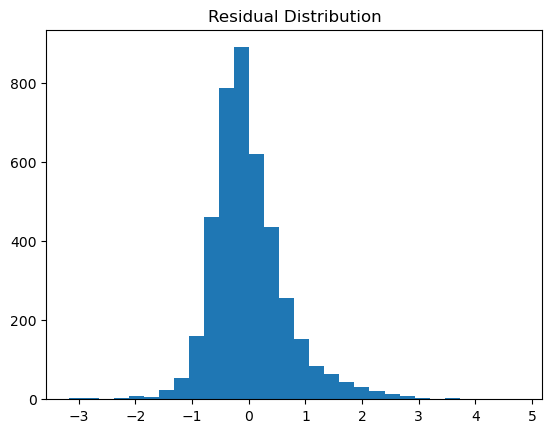

In [23]:
residuals = y_test - y_pred
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

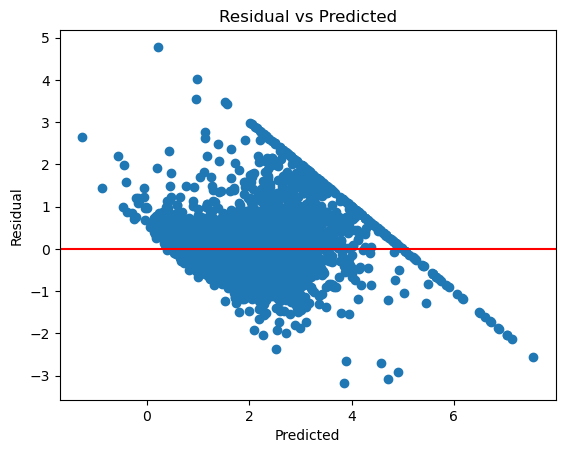

In [24]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual vs Predicted")
plt.show()

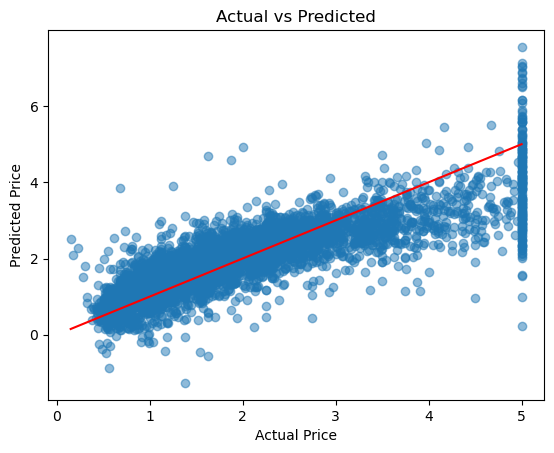

In [34]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect line
plt.show()

## Train Multiple Models

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    pipeline.fit(x_train, y_train)
    preds = pipeline.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
print(results_df)


               Model      RMSE        R2
0  Linear Regression  0.673817  0.653521
1                SVR  0.564976  0.756414
2      Decision Tree  0.709008  0.616385
3      Random Forest  0.501306  0.808222
4  Gradient Boosting  0.538437  0.778761


## Cross Validation

In [35]:
rf = RandomForestRegressor()

scores = cross_val_score(
    rf,
    x_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

rmse_scores = np.sqrt(-scores)

print("Cross Validation RMSE:", rmse_scores.mean())

Cross Validation RMSE: 0.5072765709816842


## Hyperparameter Tuning

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor()

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

## Final Evaluation

In [ ]:
final_preds = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, final_preds))
r2 = r2_score(y_test, final_preds)

print("Final RMSE:", rmse)
print("Final R2:", r2)

## Feature Importance

In [ ]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance")
plt.show()

## Model Comparison

| Model | RMSE | R² Score |
|------|------|------|
| Linear Regression |67|65|
| SVR |56|75|
| Decision Tree |70|61|
| Random Forest |50|80|
| Gradient Boosting |53|77|

## Business Interpretation

The model helps understand which factors influence house prices the most.

Key Insights:

• Median income is the strongest predictor of housing prices.

• Areas with higher income levels tend to have significantly higher house values.

• Geographic location also plays a major role in determining housing prices.

• Housing prices vary significantly across different regions.

Business Impact:

Real estate companies can use this model to estimate housing prices and identify high-value areas for investment.

Property investors can use such models to identify profitable locations before making investments.

## Conclusion

In this project, we built a machine learning model to predict housing prices in California.

Key achievements:

• Performed Exploratory Data Analysis  
• Identified important features affecting house prices  
• Built a Linear Regression baseline model  
• Performed feature selection to improve performance  

The final model achieved an R² score of approximately 0.58, indicating moderate predictive capability.